In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm

In [14]:
df = pd.read_csv("iris_dataset.csv")

print(df.head())
print(df["target"].unique())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

        target  
0  Iris-setosa  
1  Iris-setosa  
2  Iris-setosa  
3  Iris-setosa  
4  Iris-setosa  
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


In [15]:
# First two features
X = df.iloc[:, :2].values

# Convert target to binary classification
# Iris-setosa = 1
# Other classes = -1
y = np.where(df["target"] == "Iris-setosa", 1, -1)

print("Unique classes:", np.unique(y))
print("Class counts:")
print(pd.Series(y).value_counts())

Unique classes: [-1  1]
Class counts:
-1    100
 1     50
Name: count, dtype: int64


In [16]:
model = svm.SVC(kernel="linear", C=1)
model.fit(X, y)

print("SVM model trained successfully!")

SVM model trained successfully!


In [22]:
print(X.shape)
print(np.unique(y, return_counts=True))
print(model.classes_)
print(model.support_vectors_.shape)

(150, 2)
(array([-1,  1]), array([100,  50]))
[-1  1]
(18, 2)


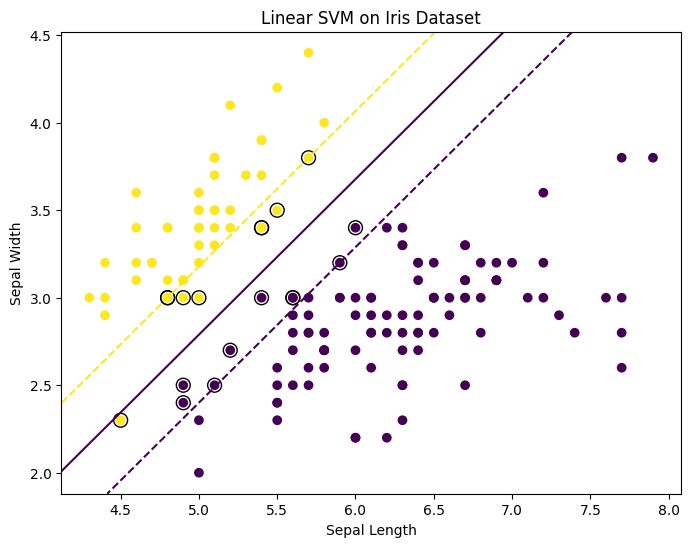

In [23]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Plot data points
ax.scatter(X[:, 0], X[:, 1], c=y)

# Get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)

YY, XX = np.meshgrid(yy, xx)

# Create coordinate pairs
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Calculate decision function
Z = model.decision_function(xy).reshape(XX.shape)

# Decision boundary
ax.contour(XX, YY, Z, levels=[0])

# Margins
ax.contour(
    XX,
    YY,
    Z,
    levels=[-1, 1],
    linestyles=["--", "--"]
)

# Support vectors
ax.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="k"
)

# Labels and title
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_title("Linear SVM on Iris Dataset")

plt.show()